**Final Project- Group 17**

# **Section 1: Loading packages and data**

In [ ]:
!pip install pregress

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pregress as pr
import seaborn as sns
import pandas as pd

In [ ]:
url = "https://raw.githubusercontent.com/DustinDiSisto/BTE320/refs/heads/main/Suspicious_Tax_Returns.csv"

df = pd.read_csv(url)
# Quick preview
df.head(20)

,Reported_Income,Claimed_Deductions_Pct,Business_Expenses,Charitable_Contributions_Pct,Home_Office_Deduction,Num_Dependents,Amended_Returns,Tax_Credits,Investment_Income_Pct,Income_Variability_Pct,Years_Since_Last_Audit,Occupation,Tax_Adjustment_Amount
0,116129,9.8,41456.25,1.3,12436.875,1,0,5264.1284,9.5,8.10,10,Lawyer,8253
1,58059,18.5,22518.75,5.3,11755.625,0,0,2148.1830,13.3,6.12,15,Doctor,10785
2,85894,14.3,29248.50,5.9,8774.550,1,1,4635.5684,7.6,13.34,5,Doctor,12174
3,93986,17.5,36305.50,7.0,10891.650,0,0,4725.5100,10.8,16.72,15,Lawyer,21910
4,87128,18.1,27794.00,8.1,8338.200,2,0,5829.0336,8.8,18.32,10,Real Estate Agent,-2524
5,71816,15.0,33751.00,3.9,10125.300,2,0,3171.4800,13.6,17.54,5,Doctor,-20093
6,120346,14.5,43233.50,6.6,15970.050,1,0,4170.0340,12.5,32.50,3,Real Estate Agent,272
7,72160,17.0,30510.00,3.9,9153.000,2,0,6677.4400,6.3,12.42,10,Real Estate Agent,13546
8,135553,17.9,44244.25,5.6,13273.275,2,0,6609.7974,9.4,11.56,10,Doctor,27698
9,73119,14.9,33130.75,3.3,9939.225,1,0,4526.9462,7.7,4.78,10,Self-Employed,-3388


$$$$
# **Section 2:** **EDA**

In [ ]:
# Drop baseline: Small Business Owner
# Baseline = Small Business Owner (no dummy created)
df["Occ_Self_Employed"] = (df["Occupation"] == "Self-Employed").astype(int)
df["Occ_Doctor"]        = (df["Occupation"] == "Doctor").astype(int)
df["Occ_Lawyer"]        = (df["Occupation"] == "Lawyer").astype(int)
df["Occ_RealEstate"]    = (df["Occupation"] == "Real Estate Agent").astype(int)
df["Occ_Small_Business_Owner"] = (df["Occupation"] == "Small Business Owner").astype(int)

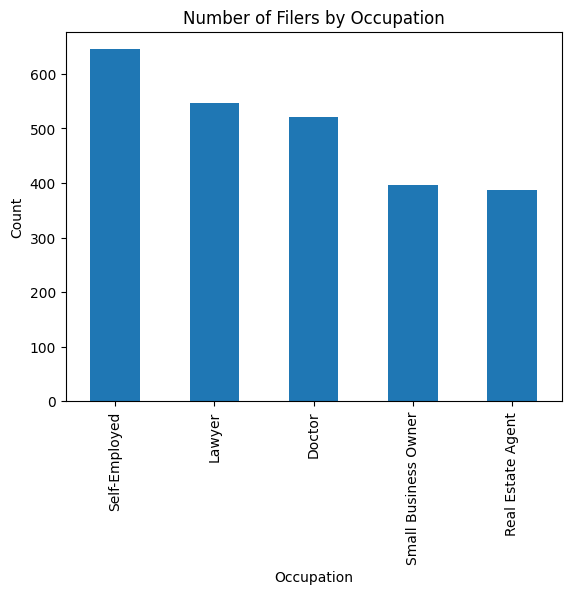

In [ ]:
df["Occupation"].value_counts().plot(kind="bar")
plt.title("Number of Filers by Occupation")
plt.ylabel("Count")
plt.show()


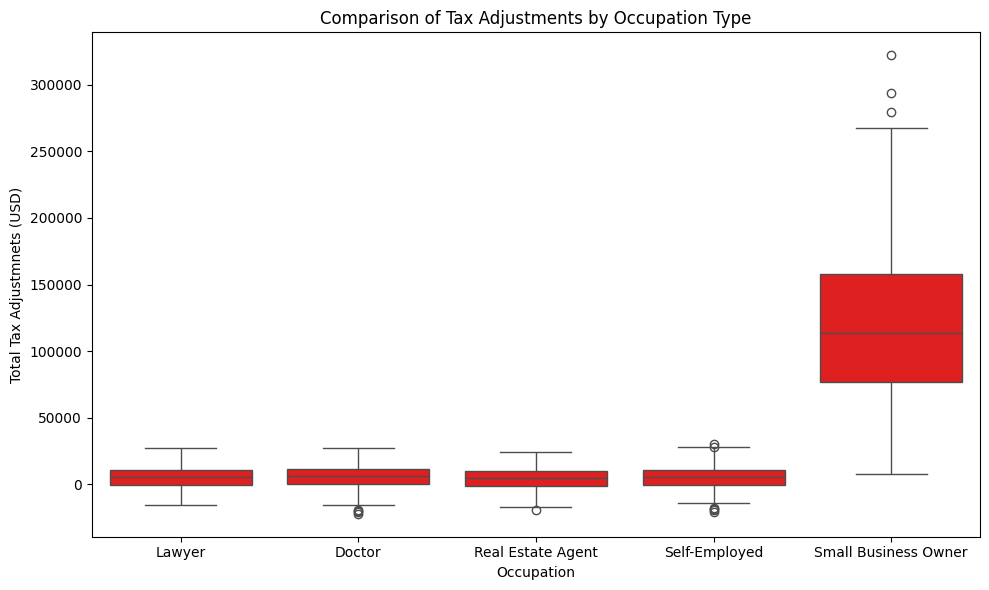

In [ ]:
pr.boxplot("Tax_Adjustment_Amount ~ Occupation", data = df, title = "Comparison of Tax Adjustments by Occupation Type", xlab = "Occupation", ylab = "Total Tax Adjustmnets (USD)")

Tax adjustment boxplots reveal striking differences across occupations:

* Small Business Owners show the highest average adjustments, suggesting this group tends to overstate deductions or underreport income.

* Real Estate Agents and Self-Employed also show elevated adjustments, consistent with industries where record-keeping is less standardized.

* Doctors and Lawyers, by contrast, show much lower average adjustments, reflecting structured financials and detailed record-keeping.

This aligns with prior IRS expectations: occupations with flexible or discretionary expenses face higher audit risk.
$$$$$$$$

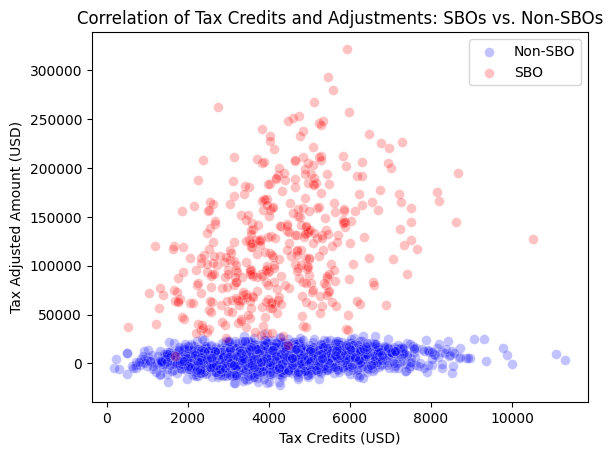

In [ ]:
colors = np.where(df["Occ_Small_Business_Owner"] == 1, "red", "blue")
pr.plot_xy("Tax_Adjustment_Amount ~ Tax_Credits", data=df, alpha = 0.24, pcolor = colors, xlab = "Tax Credits (USD)", ylab= "Tax Adjusted Amount (USD)", title = "Correlation of Tax Credits and Adjustments: SBOs vs. Non-SBOs", legend_labels = ["Non-SBO", "SBO"])

This graph compares tax credits with tax adjustments for Small Business Owners and Non–Small Business Owners. Non–Small Business Owners stay low and steady, meaning their tax adjustments don’t change much no matter how many credits they claim. Small Business Owners, on the other hand, show much bigger and less predictable adjustments, which could raise questions about how consistently they’re reporting. Keep in mind, small business owners are usually more known for claiming tax credits in general than most occupations types.

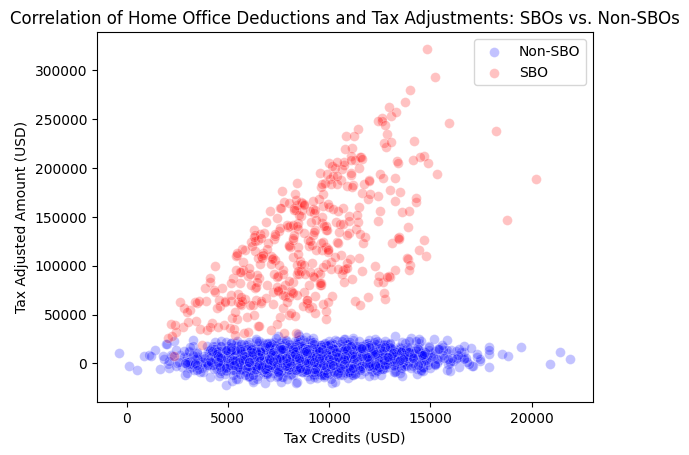

In [ ]:
pr.plot_xy("Tax_Adjustment_Amount ~ Home_Office_Deduction", data=df, alpha = 0.24, pcolor = colors, xlab = "Tax Credits (USD)", ylab= "Tax Adjusted Amount (USD)", title = "Correlation of Home Office Deductions and Tax Adjustments: SBOs vs. Non-SBOs", legend_labels = ["Non-SBO", "SBO"])

This graph shows the relationship between home office deductions and tax adjustments for Small Business Owners (SBOs) compared to Non–Small Business Owners. For Non-SBOs, tax adjustments stay relatively low and stable, no matter the size of their deductions. For SBOs, higher home office deductions are linked to much larger and more variable tax adjustments. SBOs may also be more likely to have home offices in the first place, but the wide spread in their adjustments could raise suspicion of inconsistent or inflated reporting..

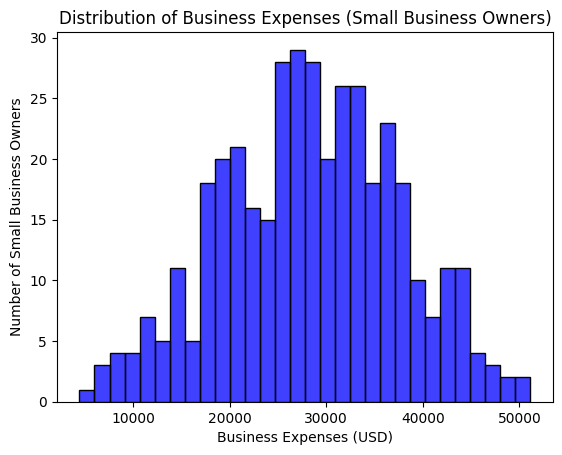

In [ ]:
# Subset only Small Business Owners
sbo = df[df["Occ_Small_Business_Owner"] == 1]

# Histogram of Tax Adjustments for SBOs
pr.hist(
    sbo["Business_Expenses"],
    bins=30,
    color="blue",
    title="Distribution of Business Expenses (Small Business Owners)",
    xlab="Business Expenses (USD)",
    ylab="Number of Small Business Owners"
)


### Histogram Interpretation

The histogram shows that most Small Business Owners report business expenses in the $20,000–$35,000 range, where the frequency peaks. However, there is a noticeable right tail, with some reporting much higher expenses, up to $50,000. While the majority fall within a common range, these unusually high expenses may raise suspicion and warrant further investigation.


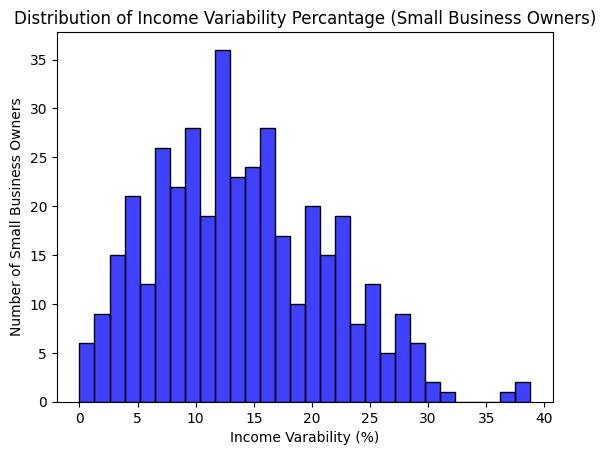

In [ ]:
# Subset only Small Business Owners
sbo = df[df["Occ_Small_Business_Owner"] == 1]

# Histogram of Tax Adjustments for SBOs
pr.hist(
    sbo["Income_Variability_Pct"],
    bins=30,
    color="blue",
    title="Distribution of Income Variability Percantage (Small Business Owners)",
    xlab="Income Varability (%)",
    ylab="Number of Small Business Owners"
)

Most small business owners report income changes from year to year in the range of about 5–20%. A smaller number show very large swings, with income changing by as much as 40%. These big jumps may point to unusual or inconsistent reporting that could be worth looking into more closely.

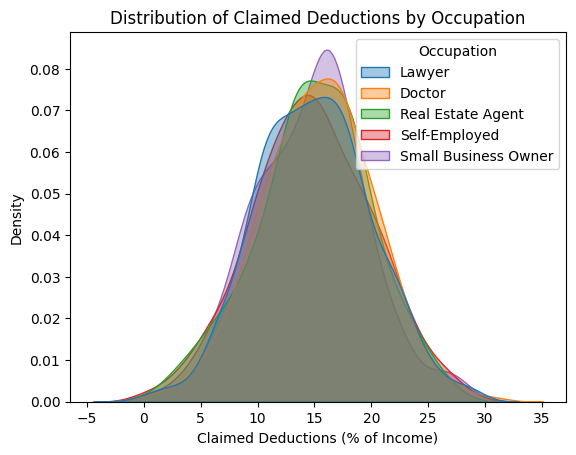

In [ ]:
sns.kdeplot(data=df, x="Claimed_Deductions_Pct", hue="Occupation", fill=True, common_norm=False, alpha=0.4)
plt.title("Distribution of Claimed Deductions by Occupation")
plt.xlabel("Claimed Deductions (% of Income)")
plt.show()



Most occupations cluster around 10–20% of income claimed as deductions, showing a common reporting range. Doctors and lawyers fall largely within this band with fewer extreme cases, while real estate agents and self-employed filers display a wider spread. Small business owners also show more variation, with some individuals claiming deductions at higher percentages of their income. Together, these patterns suggest that although most taxpayers follow similar deduction levels, certain occupation types, including small business owners, stand out with larger and more variable claims.

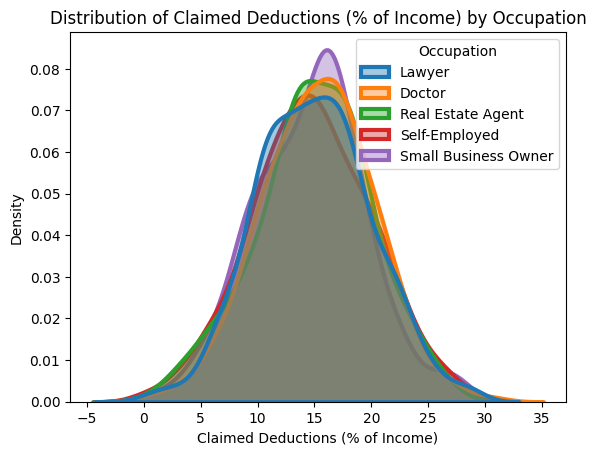

In [ ]:
sns.kdeplot(
    data=df,
    x="Claimed_Deductions_Pct",
    hue="Occupation",
    fill=True,
    common_norm=False,
    alpha=0.4,       # more transparency
    linewidth=3    # sharper edges so curves stand out
)

plt.title("Distribution of Claimed Deductions (% of Income) by Occupation")
plt.xlabel("Claimed Deductions (% of Income)")
plt.ylabel("Density")
plt.show()



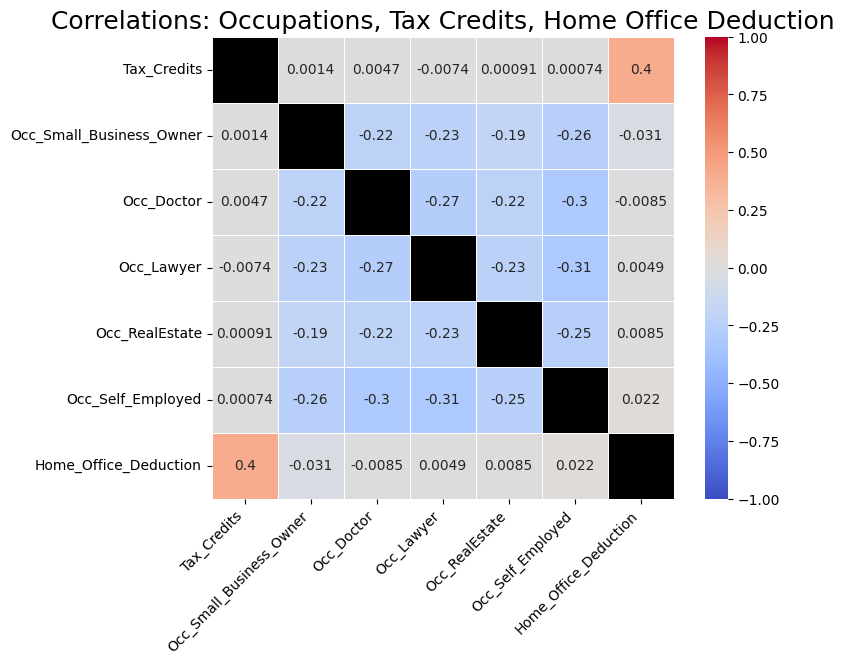

In [ ]:
pr.plot_cor("Tax_Credits ~ Occ_Small_Business_Owner + Occ_Doctor + Occ_Lawyer + Occ_RealEstate + Occ_Self_Employed + Home_Office_Deduction", data = df, main = "Correlations: Occupations, Tax Credits, Home Office Deduction", xlab= "", ylab= ""  )

The correlation matrix indicates that Tax Credits and Home Office Deduction are moderately associated (r ≈ 0.40), suggesting that taxpayers who claim one are more likely to claim the other. Correlations with occupation categories are generally weak, but Small Business Owners show relatively less negative associations compared to Doctors, Lawyers, or Self-Employed filers. This pattern does not prove misconduct on its own, but it highlights Small Business Owners as a group whose use of credits and deductions may warrant closer examination for potential irregularities.

Perform a hypothesis test to test if there is a notable difference in `Tax Credits` among occupation types by first specifying the null and alternative hypotheses and then performing the test.

We let $\mu_1$,.., $\mu_5$ represent the mean tax credits for each category (for occupations).

$$H_0: \mu_1 = ... = \mu_5$$

Alternatively, at least one is different.

In [ ]:
avo_eda = pr.fit("Tax_Credits ~ Occupation", data = df)
pr.summary(avo_eda, out = "anova")

              df        sum_sq         mean_sq         F  Pr(>F)
Regression     4  3.824327e+05    95608.167369  0.039483  0.9970
Residual    2491  6.031953e+09  2421498.558496                  
Total       2495  6.032335e+09                                  


We tested whether the mean Tax Credits differed across occupations. The ANOVA result gave an F ≈ 0.04 and a p-value of 0.997, which is far above any standard significance level. Therefore, we fail to reject the null hypothesis and conclude that average Tax Credits are not statistically different across occupation groups.

# **Section 3: Modeling Data**

In [ ]:
df.Occupation.unique()

array(['Lawyer', 'Doctor', 'Real Estate Agent', 'Self-Employed',
       'Small Business Owner'], dtype=object)

In [ ]:
# Drop baseline: Small Business Owner
# Baseline = Small Business Owner (no dummy created)
df["Occ_Self_Employed"] = (df["Occupation"] == "Self-Employed").astype(int)
df["Occ_Doctor"]        = (df["Occupation"] == "Doctor").astype(int)
df["Occ_Lawyer"]        = (df["Occupation"] == "Lawyer").astype(int)
df["Occ_RealEstate"]    = (df["Occupation"] == "Real Estate Agent").astype(int)




In [ ]:
# Fit model
model = pr.fit("Tax_Adjustment_Amount ~ .", data=df)

pr.summary(model)

Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                                       coef   std err       t     P>|t|     
Intercept                        -2954.2944  2063.512  -1.432  0.152000     
Reported_Income                      0.0267     0.031   0.853  0.394000     
Claimed_Deductions_Pct             180.3067   112.501   1.603  0.109000     
Business_Expenses                    0.2341     0.141   1.659  0.097000    .
Charitable_Contributions_Pct        69.8731   227.594   0.307  0.759000     
Home_Office_Deduction                1.2191     0.358   3.408  0.001000   **
Num_Dependents                     283.2858   371.968   0.762  0.446000     
Amended_Returns                    242.3614   601.519   0.403  0.687000     
Tax_Credits                          0.6654     0.440   1.513  0.130000     
Investment_Income_Pct               59.5734    95.947   0.621  0.535000     
Income_Variability_Pct             108.1773    63.0

In [ ]:
df = df.dropna(subset=["Tax_Adjustment_Amount"]).copy()


formula_1 = (
    "Tax_Adjustment_Amount ~ "
    "Reported_Income + "
    "Claimed_Deductions_Pct + "
    "Business_Expenses + "
    "Charitable_Contributions_Pct + "
    "Home_Office_Deduction + "
    "Num_Dependents + "
    "Amended_Returns + "
    "Tax_Credits + "
    "Investment_Income_Pct + "
    "Income_Variability_Pct + "
    "Years_Since_Last_Audit + "
    "Occ_Self_Employed + Occ_Doctor + Occ_Lawyer + Occ_RealEstate"
)


In [ ]:
model_1 = pr.fit(formula_1, data=df)
pr.summary(model_1)

Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                                     coef   std err       t     P>|t|     
Intercept                      92650.0000  2897.575  31.973  0.000000  ***
Reported_Income                    0.0267     0.031   0.853  0.394000     
Claimed_Deductions_Pct           180.3067   112.501   1.603  0.109000     
Business_Expenses                  0.2341     0.141   1.659  0.097000    .
Charitable_Contributions_Pct      69.8731   227.594   0.307  0.759000     
Home_Office_Deduction              1.2191     0.358   3.408  0.001000   **
Num_Dependents                   283.2858   371.968   0.762  0.446000     
Amended_Returns                  242.3614   601.519   0.403  0.687000     
Tax_Credits                        0.6654     0.440   1.513  0.130000     
Investment_Income_Pct             59.5734    95.947   0.621  0.535000     
Income_Variability_Pct           108.1773    63.041   1.716  0.086000    

In [ ]:
formula_2 = (
    "Tax_Adjustment_Amount ~ "
    "Reported_Income + "
    "Claimed_Deductions_Pct + "
    "Business_Expenses + "
    # "Charitable_Contributions_Pct + "  # removed
    "Home_Office_Deduction + "
    "Num_Dependents + "
    "Amended_Returns + "
    "Tax_Credits + "
    "Investment_Income_Pct + "
    "Income_Variability_Pct + "
    "Years_Since_Last_Audit + "
    "Occ_Self_Employed + Occ_Doctor + Occ_Lawyer + Occ_RealEstate"
)

model_2 = pr.fit(formula_2, data=df)
pr.summary(model_2)


Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                               coef   std err       t     P>|t|     
Intercept                92990.0000  2671.862  34.803  0.000000  ***
Reported_Income              0.0268     0.031   0.856  0.392000     
Claimed_Deductions_Pct     181.7551   112.381   1.617  0.106000     
Business_Expenses            0.2347     0.141   1.664  0.096000    .
Home_Office_Deduction        1.2168     0.358   3.403  0.001000   **
Num_Dependents             283.5808   371.899   0.763  0.446000     
Amended_Returns            238.8439   601.300   0.397  0.691000     
Tax_Credits                  0.6618     0.440   1.506  0.132000     
Investment_Income_Pct       58.8251    95.899   0.613  0.540000     
Income_Variability_Pct     108.9583    62.978   1.730  0.084000    .
Years_Since_Last_Audit      43.7286   104.496   0.418  0.676000     
Occ_Self_Employed      -116000.0000  1464.509 -79.178  0.000000  ***
O

In [ ]:
formula_3 = (
    "Tax_Adjustment_Amount ~ "
    "Reported_Income + "
    "Claimed_Deductions_Pct + "
    "Business_Expenses + "
    "Home_Office_Deduction + "
    "Num_Dependents + "
    # "Amended_Returns + "  # removed
    "Tax_Credits + "
    "Investment_Income_Pct + "
    "Income_Variability_Pct + "
    "Years_Since_Last_Audit + "
    "Occ_Self_Employed + Occ_Doctor + Occ_Lawyer + Occ_RealEstate"
)

model_3 = pr.fit(formula_3, data=df)
pr.summary(model_3)

Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                               coef   std err       t     P>|t|     
Intercept                93080.0000  2662.219  34.962  0.000000  ***
Reported_Income              0.0271     0.031   0.866  0.386000     
Claimed_Deductions_Pct     182.3483   112.352   1.623  0.105000     
Business_Expenses            0.2334     0.141   1.655  0.098000    .
Home_Office_Deduction        1.2179     0.357   3.407  0.001000   **
Num_Dependents             284.8633   371.822   0.766  0.444000     
Tax_Credits                  0.6591     0.439   1.500  0.134000     
Investment_Income_Pct       59.0883    95.880   0.616  0.538000     
Income_Variability_Pct     109.7924    62.932   1.745  0.081000    .
Years_Since_Last_Audit      43.9185   104.477   0.420  0.674000     
Occ_Self_Employed      -116000.0000  1464.173 -79.192  0.000000  ***
Occ_Doctor             -115400.0000  1530.505 -75.377  0.000000  ***
O

In [ ]:
formula_4 = (
    "Tax_Adjustment_Amount ~ "
    "Reported_Income + "
    "Claimed_Deductions_Pct + "
    "Business_Expenses + "
    "Home_Office_Deduction + "
    "Num_Dependents + "
    "Tax_Credits + "
    #investment_Income_Pct
    "Income_Variability_Pct + "
    "Years_Since_Last_Audit + "
    "Occ_Self_Employed + Occ_Doctor + Occ_Lawyer + Occ_RealEstate"
)

model_4 = pr.fit(formula_4, data=df)
pr.summary(model_4)



Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                               coef   std err       t     P>|t|     
Intercept                93520.0000  2564.897  36.460  0.000000  ***
Reported_Income              0.0275     0.031   0.878  0.380000     
Claimed_Deductions_Pct     182.8827   112.335   1.628  0.104000     
Business_Expenses            0.2331     0.141   1.654  0.098000    .
Home_Office_Deduction        1.2145     0.357   3.398  0.001000   **
Num_Dependents             295.2902   371.390   0.795  0.427000     
Tax_Credits                  0.6562     0.439   1.494  0.135000     
Income_Variability_Pct     119.7450    60.817   1.969  0.049000    *
Years_Since_Last_Audit      43.6925   104.463   0.418  0.676000     
Occ_Self_Employed      -115900.0000  1463.841 -79.201  0.000000  ***
Occ_Doctor             -115400.0000  1530.266 -75.384  0.000000  ***
Occ_Lawyer             -116100.0000  1510.972 -76.815  0.000000  ***
O

In [ ]:
formula_5 = (
    "Tax_Adjustment_Amount ~ "
    "Reported_Income + "
    "Claimed_Deductions_Pct + "
    "Business_Expenses + "
    "Home_Office_Deduction + "
    "Num_Dependents + "
    "Tax_Credits + "
    "Income_Variability_Pct + "
    #Years Since Last Audit removed
    "Occ_Self_Employed + Occ_Doctor + Occ_Lawyer + Occ_RealEstate"
)

model_5 = pr.fit(formula_5, data=df)
pr.summary(model_5)



Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                               coef   std err       t     P>|t|     
Intercept                93790.0000  2480.450  37.811  0.000000  ***
Reported_Income              0.0275     0.031   0.878  0.380000     
Claimed_Deductions_Pct     182.6773   112.315   1.626  0.104000     
Business_Expenses            0.2335     0.141   1.657  0.098000    .
Home_Office_Deduction        1.2134     0.357   3.396  0.001000   **
Num_Dependents             297.0510   371.305   0.800  0.424000     
Tax_Credits                  0.6577     0.439   1.498  0.134000     
Income_Variability_Pct     119.5024    60.804   1.965  0.049000    *
Occ_Self_Employed      -115900.0000  1462.616 -79.252  0.000000  ***
Occ_Doctor             -115300.0000  1528.620 -75.448  0.000000  ***
Occ_Lawyer             -116100.0000  1510.487 -76.832  0.000000  ***
Occ_RealEstate         -116800.0000  1637.429 -71.302  0.000000  ***



In [ ]:
formula_6 = (
    "Tax_Adjustment_Amount ~ "
    "Reported_Income + "
    "Claimed_Deductions_Pct + "
    "Business_Expenses + "
    "Home_Office_Deduction + "
    #Number of Dependents
    "Tax_Credits + "
    "Income_Variability_Pct + "
    "Occ_Self_Employed + Occ_Doctor + Occ_Lawyer + Occ_RealEstate"
)

model_6 = pr.fit(formula_6, data=df)
pr.summary(model_6)



Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                               coef   std err       t     P>|t|     
Intercept                94150.0000  2439.204  38.598  0.000000  ***
Reported_Income              0.0272     0.031   0.869  0.385000     
Claimed_Deductions_Pct     183.2822   112.305   1.632  0.103000     
Business_Expenses            0.2363     0.141   1.678  0.094000    .
Home_Office_Deduction        1.2093     0.357   3.385  0.001000   **
Tax_Credits                  0.6599     0.439   1.503  0.133000     
Income_Variability_Pct     120.6609    60.782   1.985  0.047000    *
Occ_Self_Employed      -115900.0000  1462.351 -79.255  0.000000  ***
Occ_Doctor             -115300.0000  1527.403 -75.477  0.000000  ***
Occ_Lawyer             -116000.0000  1509.787 -76.846  0.000000  ***
Occ_RealEstate         -116700.0000  1635.688 -71.342  0.000000  ***

Model Statistics:
---------------------------------------------------

In [ ]:
formula_7 = (
    "Tax_Adjustment_Amount ~ "
    "Claimed_Deductions_Pct + "
    "Business_Expenses + "
    "Home_Office_Deduction + "
    "Tax_Credits + "
    "Income_Variability_Pct + "
    "Occ_Self_Employed + Occ_Doctor + Occ_Lawyer + Occ_RealEstate"
)

model_7 = pr.fit(formula_7, data=df)
pr.summary(model_7)


Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                               coef   std err       t     P>|t|     
Intercept                94020.0000  2434.320  38.621  0.000000  ***
Claimed_Deductions_Pct     158.6090   108.652   1.460  0.144000     
Business_Expenses            0.2968     0.122   2.423  0.015000    *
Home_Office_Deduction        1.2154     0.357   3.403  0.001000   **
Tax_Credits                  0.8246     0.396   2.082  0.037000    *
Income_Variability_Pct     121.7675    60.766   2.004  0.045000    *
Occ_Self_Employed      -115900.0000  1461.953 -79.258  0.000000  ***
Occ_Doctor             -115200.0000  1526.074 -75.508  0.000000  ***
Occ_Lawyer             -116000.0000  1509.438 -76.847  0.000000  ***
Occ_RealEstate         -116700.0000  1635.549 -71.341  0.000000  ***

Model Statistics:
------------------------------------------------------
R-squared: 0.7782                AIC: 57197.1209
Adj. R-squared: 

In [ ]:
formula_8 = (
    "Tax_Adjustment_Amount ~ "
    "Business_Expenses + "
    "Home_Office_Deduction + "
    "Tax_Credits + "
    "Income_Variability_Pct + "
    "Occ_Self_Employed + Occ_Doctor + Occ_Lawyer + Occ_RealEstate"
)

model_8 = pr.fit(formula_8, data=df)
pr.summary(model_8)


Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                               coef   std err       t     P>|t|     
Intercept                95690.0000  2147.550  44.558  0.000000  ***
Business_Expenses            0.2704     0.121   2.231  0.026000    *
Home_Office_Deduction        1.2130     0.357   3.395  0.001000   **
Tax_Credits                  1.1459     0.329   3.478  0.001000   **
Income_Variability_Pct     125.2628    60.733   2.063  0.039000    *
Occ_Self_Employed      -115800.0000  1462.119 -79.227  0.000000  ***
Occ_Doctor             -115100.0000  1524.443 -75.514  0.000000  ***
Occ_Lawyer             -115900.0000  1509.030 -76.822  0.000000  ***
Occ_RealEstate         -116600.0000  1635.397 -71.310  0.000000  ***

Model Statistics:
------------------------------------------------------
R-squared: 0.7780                AIC: 57197.2595
Adj. R-squared: 0.7773           BIC: 57249.6615
F-statistic: 1089.28 on 8 and 2487 D

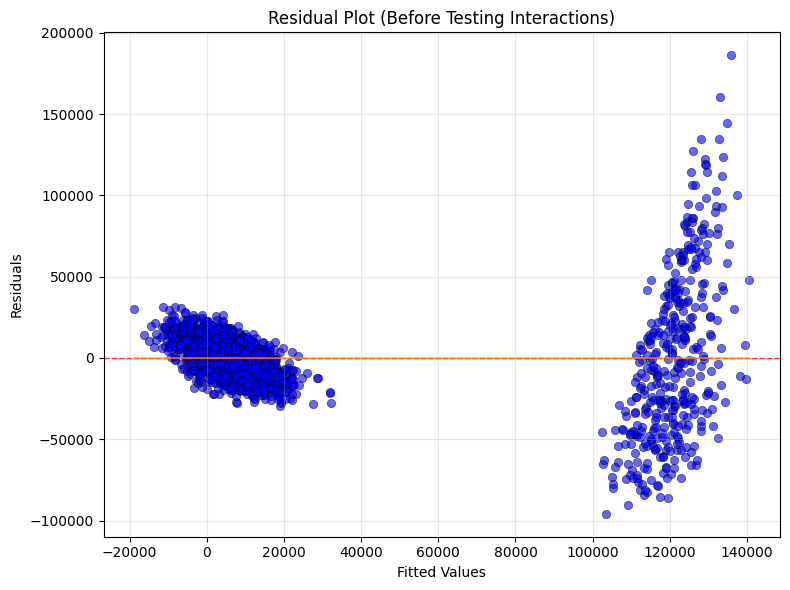

In [ ]:
pr.plot_res(model_8, main = "Residual Plot (Before Testing Interactions)", xlab = "Fitted Values", ylab = "Residuals")

Interaction testing (& changing baseline)

In [ ]:
# New baseline: all non-SBO occupations
df["Occ_Small_Business_Owner"] = (df["Occupation"] == "Small Business Owner").astype(int)


In [ ]:
formula_9 = (
    "Tax_Adjustment_Amount ~ "
    "Business_Expenses + "
    "Home_Office_Deduction + "
    "Tax_Credits + "
    "Income_Variability_Pct + "
    "Occ_Small_Business_Owner + "
    "Occ_Small_Business_Owner:Tax_Credits + "
    "Occ_Small_Business_Owner:Home_Office_Deduction "
)

model_9 = pr.fit(formula_9, data=df)

pr.summary(model_9)


Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                                                    coef   std err       t  \
Intercept                                       629.5397  1668.386   0.377   
Business_Expenses                                 0.1896     0.098   1.925   
Home_Office_Deduction                            -0.4631     0.296  -1.566   
Tax_Credits                                       0.8214     0.287   2.857   
Income_Variability_Pct                           12.8489    49.463   0.260   
Occ_Small_Business_Owner                         71.6583  3693.357   0.019   
Occ_Small_Business_Owner:Tax_Credits              3.3954     0.753   4.511   
Occ_Small_Business_Owner:Home_Office_Deduction   11.2653     0.369  30.568   

                                                   P>|t|       
Intercept                                       0.706000       
Business_Expenses                               0.054000    .  
Hom

#  **Model Diagnostics**

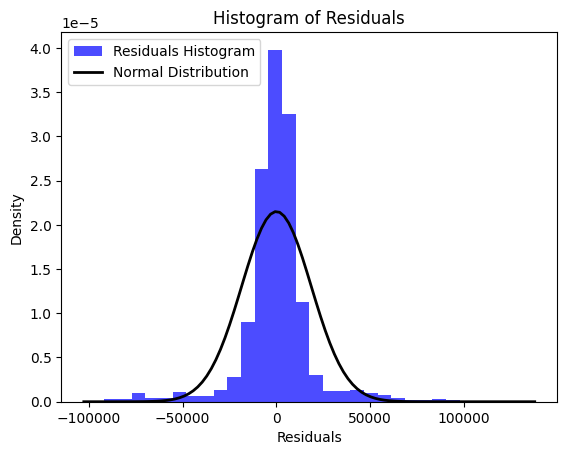

In [ ]:
pr.hist_res(model_9)

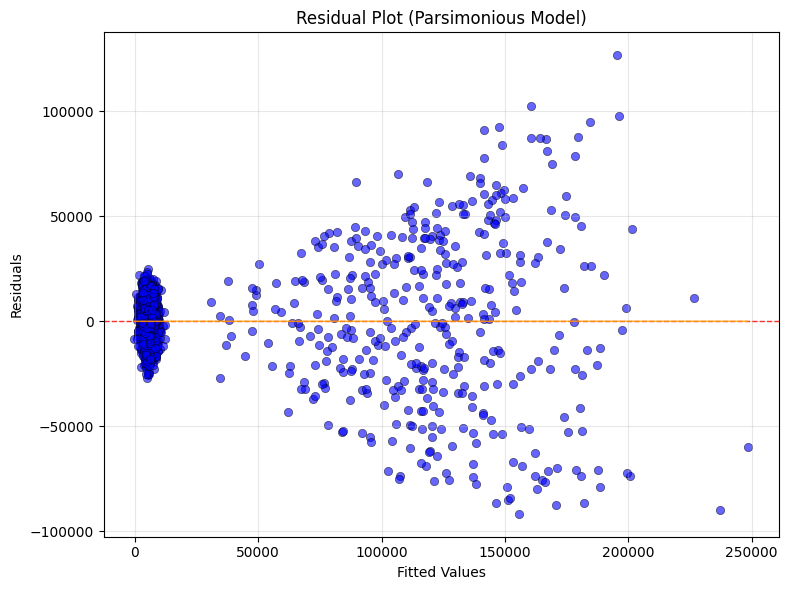

In [ ]:
pr.plot_res(model_9, main = "Residual Plot (Parsimonious Model)", xlab = "Fitted Values", ylab = "Residuals")

In [ ]:
avo_model = pr.fit("Tax_Adjustment_Amount ~ Business_Expenses + Home_Office_Deduction + Tax_Credits + Income_Variability_Pct + Occ_Small_Business_Owner + Occ_Small_Business_Owner:Tax_Credits + Occ_Small_Business_Owner:Home_Office_Deduction", data = df)
pr.summary(avo_model, out = "anova")

              df        sum_sq              mean_sq            F  Pr(>F)
Regression     7  4.993496e+12  713356580870.704102  2066.366051  0.0000
Residual    2488  8.589142e+11        345222755.001                     
Total       2495  5.852410e+12                                          


Anova test findings: “The ANOVA results (F(7, 2488) ≈ 2066.37, p < 0.0001) confirm that our predictors in our parsamonious model maintain statistical significance in explaining variation in Tax Adjustment Amount.”


**Methodology : We started with a broader model, removed non-informative terms guided by EDA, and then added interactions for Small Business Owners (SBO) based on the dataset hint that SBO returns behave differently. We selected a parsimonious final model (model_9) using interpretability and adjusted R².**

**Model Assumptions & Diagnostics**


**What we did:**
1. Verified linearity, normality of errors, and constant variance.
2. **Residuals vs Fitted** : checked linearity and any patterns, should look like a cloud around 0.
3. **Histogram of Residuals** : visual normality check, roughly bell-shaped.
4. **Residuals by Occupation** : boxplot of residuals grouped by Occupation to inspect heteroscedasticity / special behavior of small business owners.

**Interpretation Guide:**
- **Linearity:** If no strong curve/pattern in residuals vs fitted, linearity is reasonable.
- **Normality:** Histogram should look roughly bell-shaped, a few tails are okay.
- **Homoscedasticity:** If residual spread looks very different across fitted values or across occupations, especially Small Business Owners.

**Limitations & Potential Improvements:**
- If variance differs by Occupation, consider a simple transformation of the response like log of Tax_Adjustment_Amount or modeling an interaction you already justified in EDA.
- Large outliers may influence OLS.



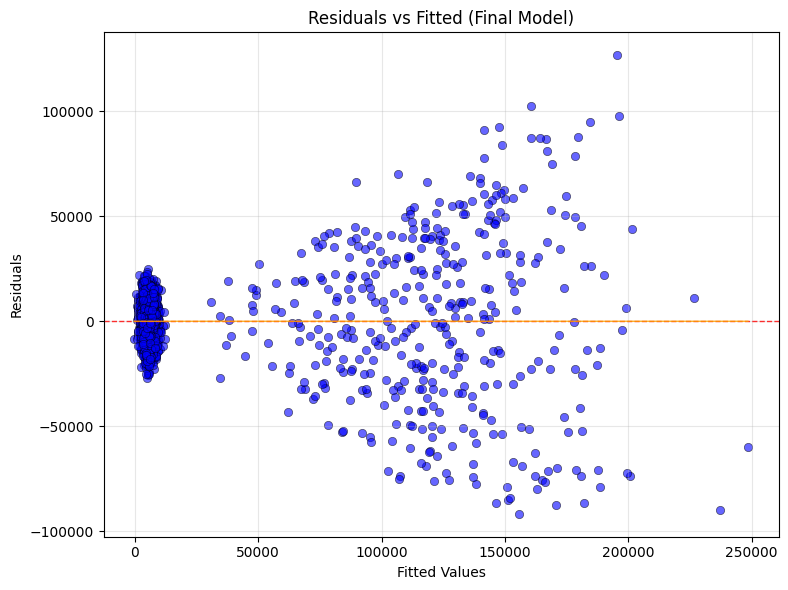

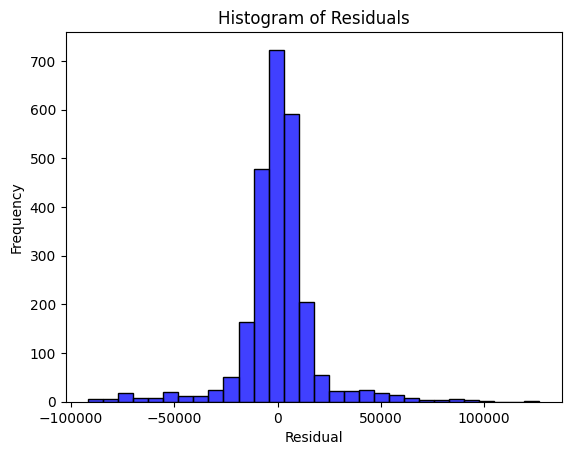

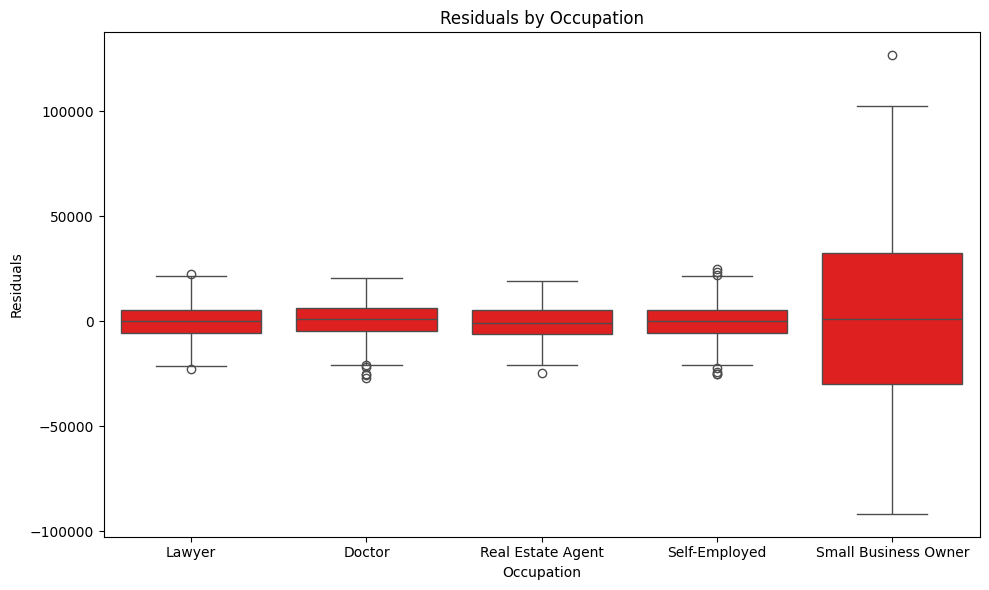


Residual spread by fitted-value quintiles:
                                 count    mean       std
Fitted                                                  
(-244.56300000000002, 4318.554]    500  971.74   7888.97
(4318.554, 5361.25]                499 -597.27   8605.60
(5361.25, 6438.852]                499 -416.16   8373.59
(6438.852, 8280.615]               499  147.44   7853.84
(8280.615, 248530.155]             499 -107.70  38144.43

Residual summary by Occupation:
                      count    mean       std
Occupation                                   
Doctor                  521  540.48   8310.63
Lawyer                  547 -151.31   8155.01
Real Estate Agent       387 -761.12   7920.01
Self-Employed           645  148.41   8323.71
Small Business Owner    396    0.00  42618.52


In [ ]:
# final model + working frame
model_final = model_9
df_diag = df.copy()

# use simple names
df_diag["Fitted"]    = model_final.fittedvalues
df_diag["Residuals"] = model_final.resid

# 1) Residuals vs Fitted (pregress)
pr.plot_res(
    model_final,
    main = "Residuals vs Fitted (Final Model)",
    xlab = "Fitted Values",
    ylab = "Residuals"
)

# 2) Histogram of residuals (pregress)
pr.hist(
    df_diag["Residuals"],
    xlab  = "Residual",
    ylab  = "Frequency",
    title = "Histogram of Residuals"
)

# 3) Residuals by Occupation (pregress boxplot)
if "Occupation" in df_diag.columns:
    pr.boxplot(
        "Residuals ~ Occupation",
        data  = df_diag,
        title = "Residuals by Occupation",   # <-- was `main`, now `title`
        ylab  = "Residuals"
    )
else:
    print("No 'Occupation' column found — skipping boxplot.")

# Small tables for the write-up
by_fit = pd.qcut(df_diag["Fitted"], q=5, duplicates="drop")
print("\nResidual spread by fitted-value quintiles:")
print(df_diag.groupby(by_fit, observed=False)["Residuals"].agg(["count","mean","std"]).round(2).to_string())

if "Occupation" in df_diag.columns:
    print("\nResidual summary by Occupation:")
    print(df_diag.groupby("Occupation", observed=False)["Residuals"].agg(["count","mean","std"]).round(2).to_string())



 **Model Interpretation & Insights**

**Adjusted R².** Our final model achieves an adjusted **R²: 0.8528.**, meeting the guideline (> 0.8) from the dataset overview.

**Key Coefficient Interpretations  (holding other variables constant):**

**Business_Expenses**: every +$1,000 → about  $189.56 more in IRS adjustment.

**Home_Office_Deduction**: every +$1,000 → about $463.05 less for non-SBO; however, for SBO the total effect flips positive to about +$10,802.21 per $1,000 (see interaction below).

**Tax_Credits**: each +$1 → about +$0.82 change for non-SBO; for SBO the total is about +$4.22 per $1 (base $0.82 + extra $3.40).
**Income_Variability_Pct**: +1 percentage point → about +$12.85 change.

**Small Business Owner** (vs baseline): average level difference +$71.66.

Interactions (SBO):

SBO × Tax_Credits: extra +$3.40 per $1, so SBO total ≈ $4.22 per $1 (0.82 + 3.40).

SBO × Home_Office_Deduction: extra +$11.2653 per $1; since the non-SBO base is −$0.4631 per $1, SBO total ≈ +$10.8022 per $1 → ≈ +$10,802.21 per $1,000.

**Practical Implications.**
- Returns with **large deductions relative to income** and **high business expenses** are more likely to face larger IRS adjustments.
- **Small Business Owners** exhibit patterns consistent with higher variance in residuals, suggesting greater uncertainty/variance in reported figures and IRS scrutiny.
- These insights can help taxpayers document deductions more carefully and anticipate potential adjustments.

**Ethical/Real-World Considerations.**
- Models like this should not be used to unfairly target specific occupations, they should inform transparent, risk-aware reviews while minimizing bias.
- Results reflect this dataset and assumptions of linear modeling. True IRS behavior can involve complex, non-linear rules outside our scope.




In [ ]:
model_final = model_9

# adjusted R^2
adj_r2 = round(model_final.rsquared_adj, 4)
print("Adjusted R^2:", adj_r2)

# quick coefficient table so I can see exact names
coef_tbl = pd.DataFrame({
    "Estimate": model_final.params,
    "Std.Err": model_final.bse
})
coef_tbl["t"] = coef_tbl["Estimate"] / coef_tbl["Std.Err"]
print("\nCoefficients (compact):")
print(coef_tbl.round(4).to_string())

# terms that are in  final formula
b = model_final.params

be = b["Business_Expenses"]
ho = b["Home_Office_Deduction"]
tc = b["Tax_Credits"]
iv = b["Income_Variability_Pct"]
sbo = b["Occ_Small_Business_Owner"]
sbo_tc = b["Occ_Small_Business_Owner:Tax_Credits"]
sbo_ho = b["Occ_Small_Business_Owner:Home_Office_Deduction"]

print("\nPlain-English numbers:")
print(f"- Business_Expenses (+$1,000): ${be*1000:,.2f}")
print(f"- Home_Office_Deduction (+$1,000): ${ho*1000:,.2f}")
print(f"- Tax_Credits (+$1): ${tc:,.2f}")
print(f"- Income_Variability_Pct (+1 pp): ${iv:,.2f}")
print(f"- Small Business Owner (vs baseline): ${sbo:,.2f}")

print("\nInteractions:")
print(f"- SBO × Tax_Credits (extra per $1): ${sbo_tc:,.2f}")
print(f"  SBO total Tax_Credits effect per $1 ≈ ${tc + sbo_tc:,.2f}")
print(f"- SBO × Home_Office_Deduction (extra per $1): ${sbo_ho:,.2f}")
print(f"  SBO total Home_Office_Deduction per $1 ≈ ${ho + sbo_ho:,.2f}")
print(f"  SBO total Home_Office_Deduction per $1,000 ≈ ${(ho + sbo_ho)*1000:,.2f}")

Adjusted R^2: 0.8528

Coefficients (compact):
                                                Estimate    Std.Err        t
Intercept                                       629.5397  1668.3856   0.3773
Business_Expenses                                 0.1896     0.0985   1.9248
Home_Office_Deduction                            -0.4631     0.2956  -1.5663
Tax_Credits                                       0.8214     0.2875   2.8571
Income_Variability_Pct                           12.8489    49.4629   0.2598
Occ_Small_Business_Owner                         71.6583  3693.3570   0.0194
Occ_Small_Business_Owner:Tax_Credits              3.3954     0.7527   4.5110
Occ_Small_Business_Owner:Home_Office_Deduction   11.2653     0.3685  30.5682

Plain-English numbers:
- Business_Expenses (+$1,000): $189.56
- Home_Office_Deduction (+$1,000): $-463.05
- Tax_Credits (+$1): $0.82
- Income_Variability_Pct (+1 pp): $12.85
- Small Business Owner (vs baseline): $71.66

Interactions:
- SBO × Tax_Credits (extra